In [1]:
import numpy as np
import pandas as pd

from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mutual_info_score, accuracy_score

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("C:/Users/Admin/Downloads/Machine-Learning/HomeWork3/course_lead_scoring_2026.csv")

In [3]:
data.shape

(5000, 9)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   lead_source               4852 non-null   object 
 1   industry                  4760 non-null   object 
 2   employment_status         4806 non-null   object 
 3   location                  4792 non-null   object 
 4   annual_income             4631 non-null   float64
 5   number_of_courses_viewed  5000 non-null   int64  
 6   interaction_count         5000 non-null   int64  
 7   lead_score                4965 non-null   float64
 8   converted                 5000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 351.7+ KB


In [5]:
data.head()

,lead_source,industry,employment_status,location,annual_income,number_of_courses_viewed,interaction_count,lead_score,converted
0,organic_search,technology,employed,europe,88160.0,3,4,0.64,1
1,social_media,technology,employed,south_america,72688.0,3,7,0.72,1
2,referral,retail,employed,europe,44697.0,3,4,0.58,1
3,paid_ads,manufacturing,student,NaN,NaN,3,6,0.57,0
4,referral,manufacturing,student,north_america,24062.0,4,5,0.62,1


In [6]:
data.nunique()

lead_source                    5
industry                       6
employment_status              4
location                       5
annual_income               4313
number_of_courses_viewed       7
interaction_count             14
lead_score                    99
converted                      2
dtype: int64

In [7]:
data.isna().sum()

lead_source                 148
industry                    240
employment_status           194
location                    208
annual_income               369
number_of_courses_viewed      0
interaction_count             0
lead_score                   35
converted                     0
dtype: int64

### Question 1

In [8]:
data['industry'].value_counts().head()

industry
technology    1173
retail         925
healthcare     840
finance        720
education      639
Name: count, dtype: int64

In [9]:
data['industry'].mode()[0]

'technology'

### Question 2

In [10]:
data_numeric = data.copy()
data_numeric = data.drop(
    ['lead_source', 'industry', 'employment_status', 'location', 'converted'],
    axis=1
)
data_numeric.describe()

,annual_income,number_of_courses_viewed,interaction_count,lead_score
count,4631.000000,5000.000000,5000.000000,4965.000000
mean,54533.212049,2.089400,4.472600,0.494767
std,21245.661710,1.188987,2.435906,0.199431
min,12000.000000,0.000000,0.000000,0.010000
25%,40458.500000,1.000000,3.000000,0.360000
50%,55051.000000,2.000000,4.000000,0.490000
75%,71252.500000,3.000000,6.000000,0.630000
max,109886.000000,6.000000,13.000000,0.990000


In [11]:
data_numeric.corr()

,annual_income,number_of_courses_viewed,interaction_count,lead_score
annual_income,1.000000,0.137542,0.106375,0.231396
number_of_courses_viewed,0.137542,1.000000,0.721609,0.769352
interaction_count,0.106375,0.721609,1.000000,0.928712
lead_score,0.231396,0.769352,0.928712,1.000000


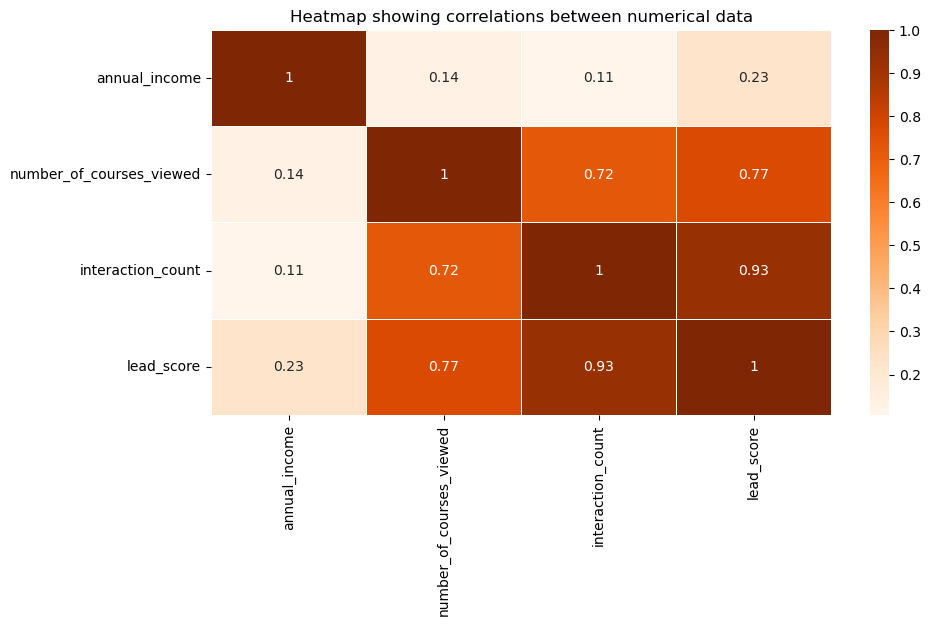

In [19]:
plt.figure(figsize=(10, 5))

sns.heatmap(
    data_numeric.corr(),
    annot=True,
    linewidth=.5,
    cmap='Oranges'
)

plt.title('Heatmap showing correlations between numerical data')
plt.show()

In [13]:
data_numeric.corr().unstack().sort_values(ascending=False)

annual_income             annual_income               1.000000
number_of_courses_viewed  number_of_courses_viewed    1.000000
interaction_count         interaction_count           1.000000
lead_score                lead_score                  1.000000
interaction_count         lead_score                  0.928712
lead_score                interaction_count           0.928712
number_of_courses_viewed  lead_score                  0.769352
lead_score                number_of_courses_viewed    0.769352
number_of_courses_viewed  interaction_count           0.721609
interaction_count         number_of_courses_viewed    0.721609
annual_income             lead_score                  0.231396
lead_score                annual_income               0.231396
annual_income             number_of_courses_viewed    0.137542
number_of_courses_viewed  annual_income               0.137542
annual_income             interaction_count           0.106375
interaction_count         annual_income               0

```number_of_courses_viewed and lead_score```

### Split the data

In [20]:
SEED = 42

df_full_train, df_test = train_test_split(
    data,
    test_size=0.2,
    random_state=SEED
)

df_train, df_val = train_test_split(
    df_full_train,
    test_size=0.25,
    random_state=SEED
)

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [15]:
assert len(data) == (len(df_train) + len(df_val) + len(df_test))

In [16]:
len(df_train), len(df_val), len(df_test)

(3000, 1000, 1000)

In [17]:
y_train = df_train['converted'].values
y_val = df_val['converted'].values
y_test = df_test['converted'].values

In [18]:
y_train[:5], len(y_train)

(array([1, 0, 1, 0, 1]), 3000)

### Question 3

In [21]:
def calculate_mi(series):
    return mutual_info_score(series, df_train.converted)

In [25]:
categorical = ['lead_source', 'industry', 'employment_status', 'location']
numerical = ['annual_income', 'number_of_courses_viewed', 'interaction_count', 'lead_score']

In [27]:
df_mi = df_train[categorical].fillna('NA').apply(calculate_mi)

df_mi = df_mi.sort_values(
    ascending=False
).to_frame(name='MI')

round(df_mi,2)

,MI
lead_source,0.03
employment_status,0.02
industry,0.00
location,0.00


```lead_source``` has the biggest score.

In [28]:
df_train = df_train.drop('converted', axis=1)
df_val = df_val.drop('converted', axis=1)
df_test = df_test.drop('converted', axis=1)

In [29]:
df_train.columns

Index(['lead_source', 'industry', 'employment_status', 'location',
       'annual_income', 'number_of_courses_viewed', 'interaction_count',
       'lead_score'],
      dtype='object')

### Question 4 — Logistic Regression

In [39]:
df_train[categorical] = df_train[categorical].fillna('NA')
df_train[numerical] = df_train[numerical].fillna(0)

In [40]:
dv = DictVectorizer(sparse=False)
train_dict = df_train.to_dict(orient='records')
X_train = dv.fit_transform(train_dict)

In [41]:
model  = LogisticRegression(
    solver='liblinear',
    C=1.0,
    max_iter=1000,
    random_state=42
)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'


In [45]:
df_val[categorical] = df_val[categorical].fillna('NA')
df_val[numerical] = df_val[numerical].fillna(0)

val_dict = df_val.to_dict(orient='records')
X_val = dv.transform(val_dict)

y_pred = model.predict(X_val)

In [46]:
original_score = accuracy_score(y_val, y_pred)
original_score

0.645

In [47]:
accuracy = np.round(original_score, 2)
print('Accuracy:', accuracy)

Accuracy: 0.64


### Question 5

In [54]:
features = df_train.columns.to_list()
eliminate = [
    'lead_source',
    'number_of_courses_viewed',
    'interaction_count']

In [56]:
scores = pd.DataFrame(columns=['eliminated_feature', 'accuracy', 'difference'])
for feature in eliminate:
    subset = features.copy()
    subset.remove(feature)
    
    dv = DictVectorizer(sparse=False)
    train_dict = df_train[subset].to_dict(orient='records')
    X_train = dv.fit_transform(train_dict)

    model = LogisticRegression(
        C=1,
        max_iter=100000,
        random_state=42
    )
    model.fit(X_train, y_train)
    
    val_dict = df_val[subset].to_dict(orient='records')
    X_val = dv.transform(val_dict)
    
    y_pred = model.predict(X_val)
    score = accuracy_score(y_val, y_pred)
    
    scores.loc[len(scores)] = [feature, score, original_score - score]

In [57]:
scores

,eliminated_feature,accuracy,difference
0,lead_source,0.717,-0.072
1,number_of_courses_viewed,0.715,-0.070
2,interaction_count,0.733,-0.088


```interaction_count```

### Question 6

In [58]:
y_train.shape, y_val.shape

((3000,), (1000,))

In [60]:
dv = DictVectorizer(sparse=False)
train_dict = df_train.to_dict(orient='records')
X_train = dv.fit_transform(train_dict)

val_dict = df_val.to_dict(orient='records')
X_val = dv.transform(val_dict)

In [62]:
scores = {}
for C in [0.000001, 0.00001, 0.0001, 0.001]:
    model = LogisticRegression(
        solver='liblinear',
        C=C,
        max_iter=1000,
        random_state=42
    )
    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)

    score = accuracy_score(y_val, y_pred)
    scores[C] = round(score, 3)
    print(f'C = {C}: Accuracy = {score:.3f}')

C = 1e-06: Accuracy = 0.598
C = 1e-05: Accuracy = 0.598
C = 0.0001: Accuracy = 0.613
C = 0.001: Accuracy = 0.645


``` 0.001 Highest Accuracy = 0.645```